In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/processed/cleaned_train.csv")

print(df.shape)
df.head()

(7613, 7)


,id,keyword,location,text,target,text_length,cleaned_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,deeds reason earthquake may allah forgive us
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,residents asked shelter place notified officer...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,13000 people receive wildfires evacuation orde...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,got sent photo ruby alaska smoke wildfires pou...


In [5]:
df.info()
df.columns
df["target"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            7613 non-null   int64
 1   keyword       7552 non-null   str  
 2   location      5080 non-null   str  
 3   text          7613 non-null   str  
 4   target        7613 non-null   int64
 5   text_length   7613 non-null   int64
 6   cleaned_text  7613 non-null   str  
dtypes: int64(3), str(4)
memory usage: 1.8 MB


target
0    4342
1    3271
Name: count, dtype: int64

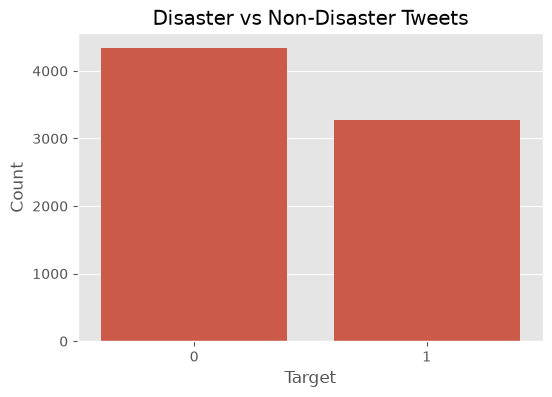

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="target")

plt.title("Disaster vs Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [7]:
import re
import string

In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

# Count unique words to measure vocabulary diversity
df["unique_word_count"] = df["text"].apply(
    lambda x: len(set(x.split()))
)

df["avg_word_length"] = df["text"].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split())
)

In [14]:
df["uppercase_count"] = df["text"].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

df["digit_count"] = df["text"].apply(
    lambda x: sum(1 for c in x if c.isdigit())
)

df["punctuation_count"] = df["text"].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

In [15]:
df["hashtag_count"] = df["text"].apply(
    lambda x: len(re.findall(r"#\w+", x))
)

df["mention_count"] = df["text"].apply(
    lambda x: len(re.findall(r"@\w+", x))
)

df["url_count"] = df["text"].apply(
    lambda x: len(re.findall(r"http\S+|www\.\S+", x))
)

In [17]:
df[
    [
        "text_length",
        "word_count",
        "unique_word_count",
        "avg_word_length",
        "uppercase_count",
        "digit_count",
        "punctuation_count",
        "hashtag_count",
        "mention_count",
        "url_count"
    ]
].head()

,text_length,word_count,unique_word_count,avg_word_length,uppercase_count,digit_count,punctuation_count,hashtag_count,mention_count,url_count
0,69,13,13,4.384615,10,0,1,1,0,0
1,38,7,7,4.571429,5,0,1,0,0,0
2,133,22,20,5.090909,2,0,3,0,0,0
3,65,8,8,7.125000,1,5,2,1,0,0
4,88,16,15,4.500000,3,0,2,2,0,0


In [18]:
# Compare feature statistics for each target class
# Helps us identify whether any feature shows a meaningful difference b/w the two classes

feature_cols = [
    "text_length",
    "word_count",
    "unique_word_count",
    "avg_word_length",
    "uppercase_count",
    "digit_count",
    "punctuation_count",
    "hashtag_count",
    "mention_count",
    "url_count",
]

df.groupby("target")[feature_cols].mean().round(2)

,text_length,word_count,unique_word_count,avg_word_length,uppercase_count,digit_count,punctuation_count,hashtag_count,mention_count,url_count
target,,,,,,,,,,
0,95.71,14.70,14.10,5.87,9.21,1.59,6.31,0.39,0.42,0.51
1,108.11,15.17,14.66,6.47,10.87,2.64,7.54,0.50,0.27,0.77


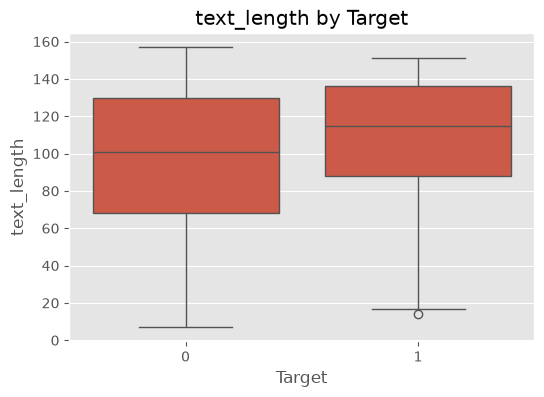

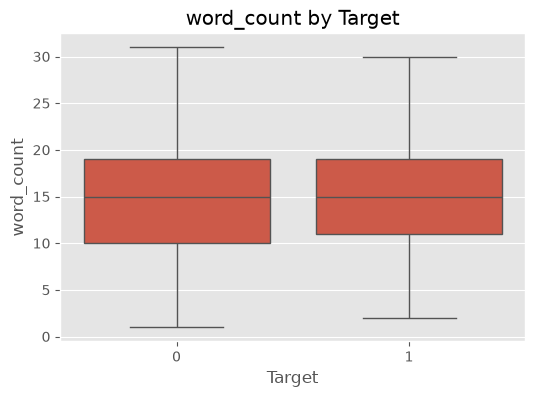

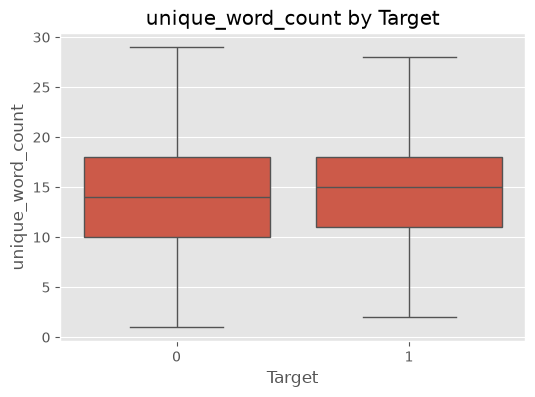

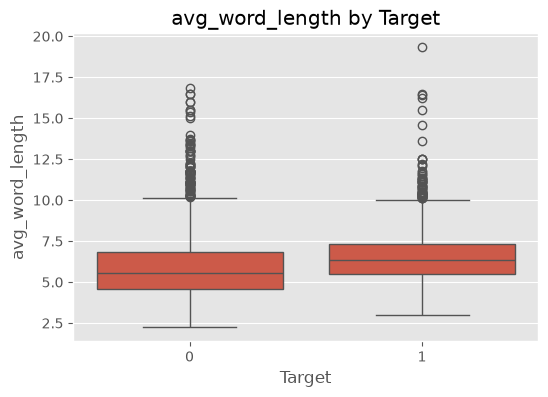

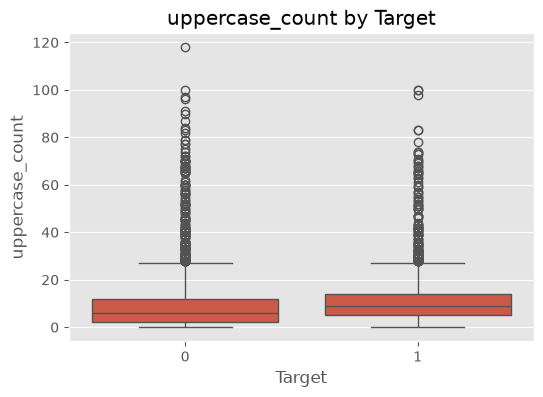

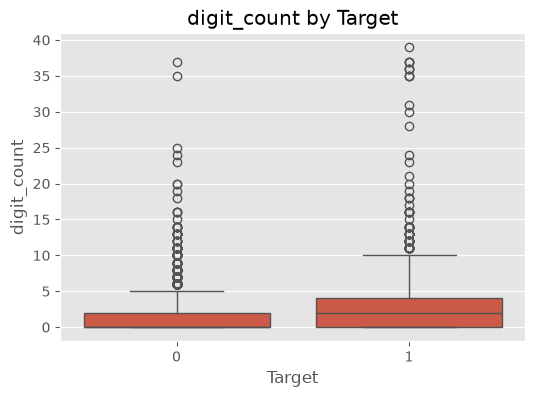

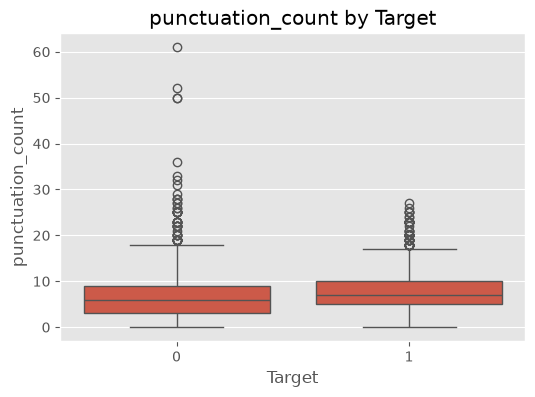

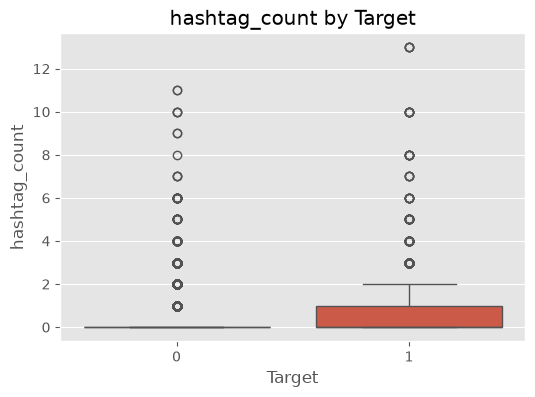

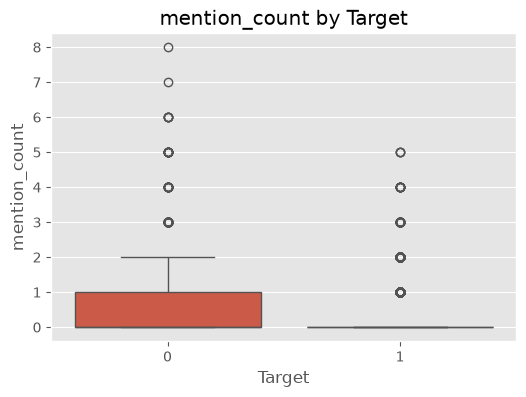

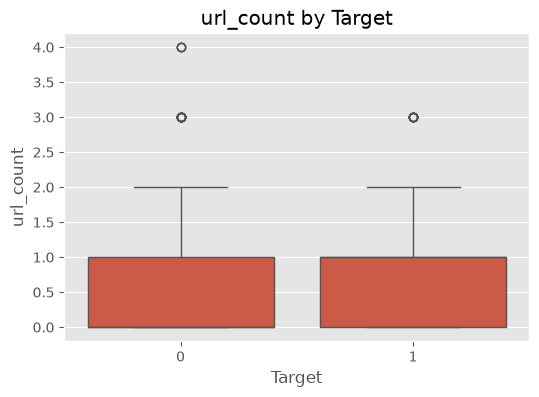

In [19]:
# Create boxplots for all engineered features
# visualize the distribution of each feature and identify potential differences 
# or outliers between disaster & non-disaster tweets.

for feature in feature_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="target",
        y=feature,
    )

    plt.title(f"{feature} by Target")
    plt.xlabel("Target")
    plt.ylabel(feature)

    plt.show()

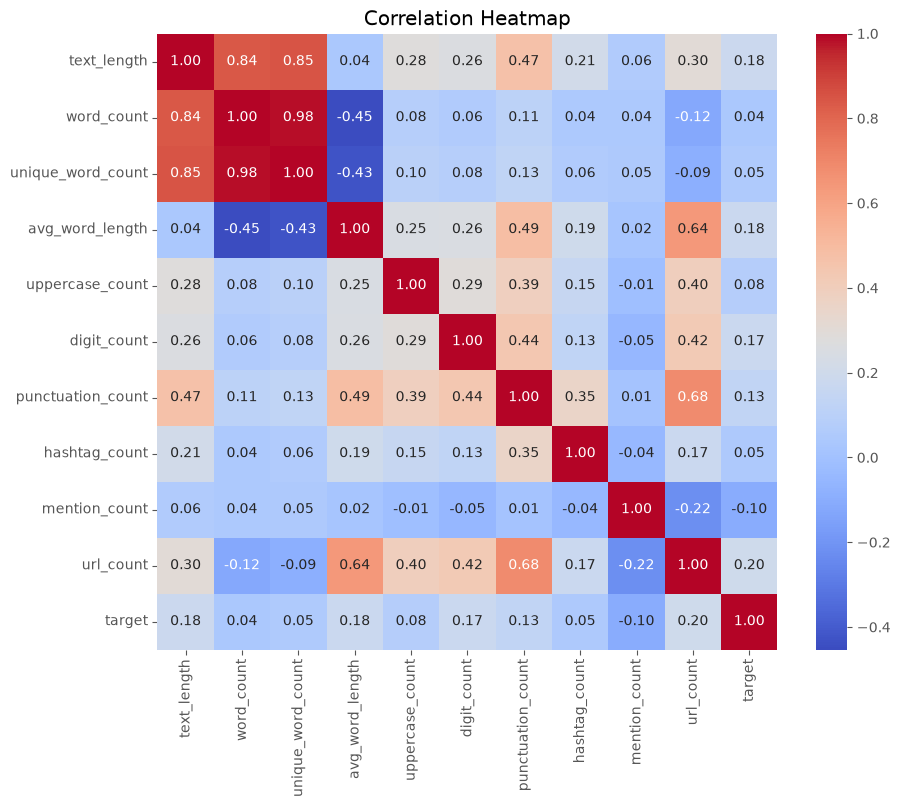

In [20]:
# Compute correlation matrix for numerical features
# heatmap helps us understand relationships between 
# engineered features and identify redundant or strongly related variables
plt.figure(figsize=(10, 8))

corr = df[feature_cols + ["target"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observations

1. **Text length, word count, and unique word count are highly positively correlated.**
   - `word_count` and `unique_word_count` have a correlation of **0.98**, indicating that longer tweets generally contain more unique words.

2. **Average word length has a moderate negative correlation with word count (-0.45).**
   - Tweets with more words tend to have slightly shorter average word lengths.

3. **URL count shows the highest positive correlation with the target (0.20).**
   - This suggests disaster-related tweets are slightly more likely to contain URLs, although the relationship is weak.

4. **Text length and average word length have a weak positive correlation with the target (0.18 each).**
   - Disaster tweets tend to be marginally longer and contain slightly longer words on average.

5. **Most engineered features have weak correlations with the target.**
   - This indicates that these handcrafted numerical features alone are unlikely to be strong predictors, highlighting the importance of using text vectorization techniques such as TF-IDF or word embeddings.

#### TF-IDF Vectorization

- ML models cannot understand raw text directly.
- We'll convert cleaned tweets into numerical feature vectors using TF-IDF.
- TF-IDF assigns higher importance to words that are frequent in a document but relatively rare across the entire dataset, helping the model focus on informative words while reducing the influence of very common words.

In [22]:
#Before vectorizing the text, separate the input features (`X`) from the target labels (`y`).

#Input feature
X = df["cleaned_text"]

#Target label
y = df["target"]

In [24]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)
# Stratify preserves class distribution

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 6090
Testing samples  : 1523


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Keep the 5000 most informative words
    ngram_range=(1, 2),     # Use both single words (unigrams) and pairs of words (bigrams)
    min_df=2,               # Ignore words appearing in only one document
    max_df=0.95             # Ignore extremely common words
)

### Fit the Vectorizer

The vectorizer learns the vocabulary from the training data and converts the tweets into TF-IDF feature vectors.

**Important:** We fit the vectorizer only on the training data to avoid data leakage.

In [27]:
# Learn the vocabulary and transform the training data into TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert the test data using the learned vocabulary
X_test_tfidf = tfidf.transform(X_test)


### Baseline Model - Logistic Regression

We'll train our first machine learning model using **Logistic Regression**.

Although the name contains "Regression", it is commonly used for **binary classification** problems such as predicting whether a tweet is related to a disaster or not.

This baseline model provides a reference point for comparing more advanced models later in the project.

In [29]:
#Train the Logistic Regression Model

# Training the model using the TF-IDF features extracted from the training dataset.

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model using the training data
log_reg.fit(X_train_tfidf, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [30]:
# Predict class labels for the test dataset
y_pred = log_reg.predict(X_test_tfidf)

### Evaluate Model Performance

We'll evaluate the model using several classification metrics instead of relying only on accuracy.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Accuracy  : 0.8221
Precision : 0.8488
Recall    : 0.7125
F1 Score  : 0.7747


### Observations

1. The Logistic Regression model achieved an accuracy of **82.2%**, providing a strong baseline for disaster tweet classification.

2. The model achieved a high precision (**84.9%**), indicating that most tweets predicted as disasters were correctly classified.

3. The recall (**71.3%**) is lower than the precision, suggesting that the model misses some actual disaster-related tweets.

4. The F1-score (**77.5%**) demonstrates a good balance between precision and recall, making Logistic Regression an effective baseline model for this dataset.

5. Future improvements may be achieved by experimenting with other algorithms, hyperparameter tuning, or transformer-based models such as BERT.

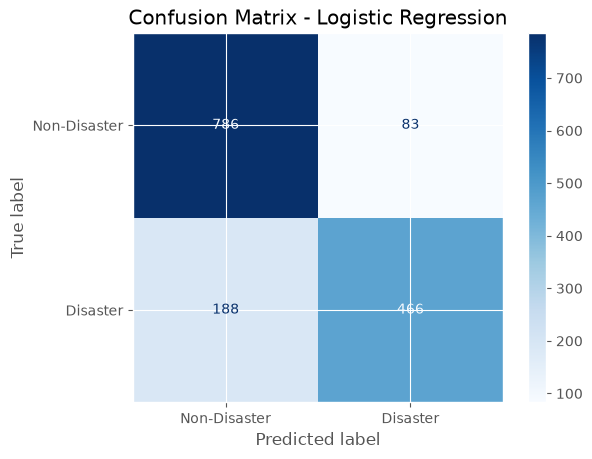

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observations

- True Negative (TN) = 786
- False Positive (FP) = 83
- False Negative (FN) = 188
- True Positive (TP) = 466

- The model correctly classifies most non-disaster tweets and produces relatively few false alarms. However, it misses 188 actual disaster tweets, resulting in lower recall. For a disaster detection application, improving recall is important because failing to identify a real disaster can have more severe consequences than issuing an extra false alarm. In future work, I would experiment with decision threshold tuning, class weighting, or alternative models such as Linear SVM or BERT to improve recall.


In [34]:
from sklearn.metrics import classification_report

# Generate the classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Disaster", "Disaster"]
    )
)

              precision    recall  f1-score   support

Non-Disaster       0.81      0.90      0.85       869
    Disaster       0.85      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



### Observations

1. The Logistic Regression model achieved an overall accuracy of **82.2%**, indicating strong baseline performance on the disaster tweet classification task.

2. The model performed better on the **Non-Disaster** class, achieving a recall of **90%**, meaning it correctly identified most non-disaster tweets.

3. For the **Disaster** class, the model achieved a high precision of **85%**, indicating that most tweets predicted as disasters were indeed disaster-related.

4. The recall for the **Disaster** class was **71%**, showing that the model missed a portion of actual disaster tweets. Improving recall would be beneficial for real-world disaster detection systems where missing true disaster events can have serious consequences.

5. The weighted average F1-score of **82%** demonstrates that the Logistic Regression model provides a strong baseline, although future models may improve the balance between precision and recall.

## Model Comparison

Logistic Regression provided a strong baseline performance. In this section, we'll train multiple machine learning algorithms using the same TF-IDF features and compare their performance.

This helps identify the most suitable model for disaster tweet classification.

In [35]:
# Train a Multinomial Naive Bayes Classifier
# Using the TF-IDF feature vectors and compare its performance with Logistic Regression.

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate the model
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")


Accuracy : 0.8096
Precision: 0.8583
Recall   : 0.6667
F1 Score : 0.7504


In [36]:
# Store model performance in a DataFrame
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Accuracy": [accuracy, nb_accuracy],
    "Precision": [precision, nb_precision],
    "Recall": [recall, nb_recall],
    "F1 Score": [f1, nb_f1]
})

# Round values for readability
comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8221,0.8488,0.7125,0.7747
1,Multinomial Naive Bayes,0.8096,0.8583,0.6667,0.7504


## Linear Support Vector Machine (Linear SVM)

Unlike Logistic Regression, which estimates probabilities, Linear SVM focuses on finding the optimal decision boundary that maximizes the separation between classes.

In [37]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create the Linear SVM model
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Accuracy : 0.7846
Precision: 0.7539
Recall   : 0.7401
F1 Score : 0.7469


In [38]:
# Add Linear SVM results to the comparison table
comparison_df.loc[len(comparison_df)] = [
    "Linear SVM",
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1
]

# Round values for readability
comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8221,0.8488,0.7125,0.7747
1,Multinomial Naive Bayes,0.8096,0.8583,0.6667,0.7504
2,Linear SVM,0.7846,0.7539,0.7401,0.7469


In [39]:
from sklearn.model_selection import cross_val_score

# Create a fresh Logistic Regression model
log_reg_cv = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Perform 5-fold cross validation
cv_scores = cross_val_score(
    log_reg_cv,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-validation scores: [0.79474548 0.79474548 0.79064039 0.80541872 0.79146141]

Mean Accuracy: 0.7954
Standard Deviation: 0.0053


In [40]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [41]:
# Create the base Logistic Regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Perform Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Search for the best hyperparameter
grid_search.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

In [42]:
# Display the best hyperparameter combination
print("Best Parameters:", grid_search.best_params_)

# Display the best cross-validation score
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 1}
Best CV Accuracy: 0.7954


### Retrieve the Best Model

GridSearchCV automatically stores the best-performing model.

GridSearchCV systematically evaluates multiple hyperparameter combinations using cross-validation. This provides a more reliable and reproducible approach to model optimization than manually trying different values, while reducing the risk of selecting a model based on a single train-test split.

In [43]:
# Retrieve the optimized model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test_tfidf)

# Evaluate the optimized model
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")

Accuracy : 0.8221
Precision: 0.8488
Recall   : 0.7125
F1 Score : 0.7747
